# Wave Equation Physics Informed Neural Network (PINN)

## Benchmark Analytical Reference Problem & Solution

### Reference Problem
Obtain the natural frequencies of a uniform string with fixed-free boundary conditions (i.e. fixed at one end and free at the other). The string has mass per unit length $\rho$, internal tension $P$, and length $l$.

### Analytical Solution
#### 1. Wave Equation & General Solution
The 1D wave equation for a string with wave speed $c = \sqrt{\frac{P}{\rho}}$ is:
$$\frac{\partial^2 w}{\partial t^2} = c^2 \frac{\partial^2 w}{\partial x^2}$$
Where $w(x,t)$ is the transverse displacement of the string at position $x$ and time $t$.

Using separation of variables, we assume the solution takes the form $w(x,t) = W(x)T(t)$, where $W(x)$ represents the spatial amplitude (or mode shape) of the string, and $T(t)$ represents the temporal oscillation (how that shape vibrates over time). The general spatial solution is:
$$W(x) = A \cos \frac{\omega x}{c} + B \sin \frac{\omega x}{c}$$

---

#### 2. Applying Boundary Conditions

**Fixed at $x = 0$:**
Displacement is zero.
$$W(0) = A \cos(0) + B \sin(0) = 0 \implies A = 0$$
This leaves: $W(x) = B \sin \frac{\omega x}{c}$

**Free at $x = l$:**
Transverse tension is zero, meaning $\frac{\partial W(l)}{\partial x} = 0$. 
Taking the derivative of our simplified $W(x)$ and evaluating at $x = l$:
$$B \frac{\omega}{c} \cos \frac{\omega l}{c} = 0$$

---

#### 3. Natural Frequencies

For a valid non-zero solution, the cosine term must equal zero:
$$\cos \frac{\omega l}{c} = 0$$

Cosine is zero at odd multiples of $\frac{\pi}{2}$:
$$\frac{\omega l}{c} = \frac{\pi}{2}(2k + 1) \quad \text{for } k = 0, 1, 2, \dots$$

Solving for $\omega$ and substituting $c = \sqrt{\frac{P}{\rho}}$ yields the final natural frequencies:
$$\omega_k = \frac{\pi}{2l}\sqrt{\frac{P}{\rho}}(2k + 1) \quad \text{for } k = 0, 1, 2, \dots$$

### Benchmark Problem: Fixed-Free String

**Parameters:**
* Length ($l$): 1.0 m
* Internal Tension ($P$): 100 N
* Mass per unit length ($\rho$): 0.01 kg/m

#### 1. Wave Speed
$$c = \sqrt{\frac{P}{\rho}} = \sqrt{\frac{100}{0.01}} = 100 \text{ m/s}$$

#### 2. Natural Frequency Equations
$$\omega_k = \frac{c\pi}{2l}(2k + 1)$$

Substitute $c = 100$ and $l = 1.0$ to get the angular frequency (rad/s):
$$\omega_k = 50\pi(2k + 1)$$

Convert to standard frequency in Hertz (Hz):
$$f_k = \frac{\omega_k}{2\pi} = 25(2k + 1)$$

#### 3. Exact Eigenfrequencies (First 4 Modes)
* **Mode 1 (Fundamental, $k=0$):** $f_0 = 25 \text{ Hz}$ ($\omega_0 = 50\pi \approx 157.08 \text{ rad/s}$)
* **Mode 2 ($k=1$):** $f_1 = 75 \text{ Hz}$ ($\omega_1 = 150\pi \approx 471.24 \text{ rad/s}$)
* **Mode 3 ($k=2$):** $f_2 = 125 \text{ Hz}$ ($\omega_2 = 250\pi \approx 785.40 \text{ rad/s}$)
* **Mode 4 ($k=3$):** $f_3 = 175 \text{ Hz}$ ($\omega_3 = 350\pi \approx 1099.56 \text{ rad/s}$)

## Numerical Simulation

In the analytical solution, we eliminated the time dependency in order to be able to solve for the natural frequencies. We could do the same for the numerical solution (making it Modal Analysis), but to leverage the power of computational mechanics, we will solve this problem more generally by retaining both spatial and time dependencies.

To do this, we will solve the wave PDE generally using Direct Time Integration.

### Direct Time Integration of the 1D Wave Equation

To simulate how a disturbance propagates through the string over time, we use Direct Time Integration. We avoid the assumption of harmonic motion and instead track the transient response by discretizing both space and time.

#### 1. Discretized Wave Equation
The 1D wave equation in terms of wave speed $c = \sqrt{P/\rho}$:
$$\frac{\partial^2 w}{\partial t^2} = c^2 \frac{\partial^2 w}{\partial x^2}$$

We introduce a discrete grid in space ($\Delta x$) and time ($\Delta t$). The displacement at spatial node $i$ and time step $n$ is denoted as $W_i^n$. 

We can apply a second-order central difference approximation to the wave equation:
$$\frac{W_i^{n+1} - 2W_i^n + W_i^{n-1}}{\Delta t^2} = c^2 \frac{W_{i+1}^n - 2W_i^n + W_{i-1}^n}{\Delta x^2}$$

#### 2. Explicit Update Rule
We can rearrange this equation to solve explicitly for the future displacement $W_i^{n+1}$ in terms of the current ($n$) and previous ($n-1$) states. Let $C = c \frac{\Delta t}{\Delta x}$:

$$W_i^{n+1} = 2W_i^n - W_i^{n-1} + C^2 \left( W_{i+1}^n - 2W_i^n + W_{i-1}^n \right)$$

This algebraic update rule is applied iteratively to all internal nodes to advance the simulation forward in time.

#### 3. Boundary Conditions
The boundaries dictate the behavior at the edges of the spatial domain (nodes $1$ and $N$).

* **Fixed End ($x=0$):** Displacement is zero at all times.
    $$W_1^{n+1} = 0$$
* **Free End ($x=l$):** Tension is zero ($\frac{\partial W}{\partial x} = 0$). We enforce this using an additional fake node outside the domain boundary to create a zero slope (first derivatve) at the last node.
    $$W_{N+1}^n = W_{N-1}^n$$

#### 4. Stability Condition
Because this is an explicit integration scheme, numerical stability is conditional. The time step $\Delta t$ must be sufficiently small relative to the grid spacing $\Delta x$ so that information does not travel more than one grid cell per computational time step.

This physical requirement is defined by the Courant-Friedrichs-Lewy (CFL) condition:
$$C = c \frac{\Delta t}{\Delta x} \le 1$$

If this limit is violated ($C > 1$), the explicit numerical solution will become unstable and diverge exponentially.

### Numerical Problem Simulation

We set up the problem as follows:

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import time


# problem params
LENGTH = 1.0 # meters
TENSION = 100.0 # Newtons
DENSITY = 0.01 # kg/m
WAVE_SPEED = np.sqrt(TENSION / DENSITY) # m/s

# spatial params
NUM_NODES = 2000 # number of spatial nodes
SPATIAL_STEP_SIZE = LENGTH / (NUM_NODES - 1)
SPATIAL_DOMAIN = np.arange(0, LENGTH, SPATIAL_STEP_SIZE)

# CFL stability condition
C = 1.0

# time params
TIME_STEP_SIZE = C * SPATIAL_STEP_SIZE / WAVE_SPEED # seconds
TOTAL_TIME = 2.0 # seconds
NUM_TIME_STEPS = int(TOTAL_TIME / TIME_STEP_SIZE)
TIME = np.linspace(0, TOTAL_TIME, NUM_TIME_STEPS)

Because we are solving for the general response of the cable in time, we will not directly get the solution to the natural frequencies of the cable. These can be determinal using signal processing from data collected in the simulation.

In order to see the cable's response across multiple natural frequencies, we will use broadband excitation in the form of a Gaussian pulse to excite multiple frequencies in the cable.

We generate the initial shape of the cable following the Gaussian pulse.

(np.float64(-0.049999999999999996),
 np.float64(1.0499999999999998),
 np.float64(-0.0049999799800250705),
 np.float64(0.10499957958052648))

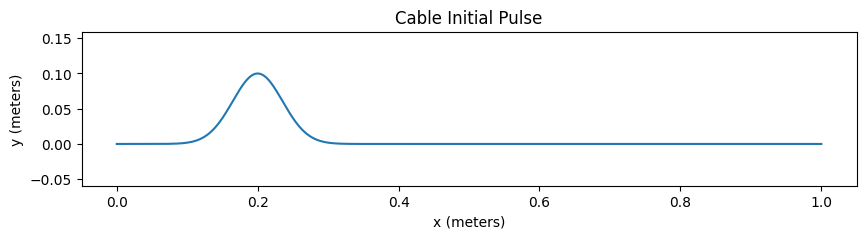

In [18]:
PULSE_MEAN = 0.2
PULSE_SIGMA = 0.05
PULSE_SCALE = 0.1
PULSE = PULSE_SCALE * np.exp(-((SPATIAL_DOMAIN - PULSE_MEAN) / PULSE_SIGMA)**2)

# ensure fixed boundary
PULSE[0] = 0.0

plt.figure(figsize=(10, 2))
plt.plot(SPATIAL_DOMAIN, PULSE)
plt.title('Cable Initial Pulse')
plt.xlabel('x (meters)')
plt.ylabel('y (meters)')
plt.axis('equal')

Now we can go ahead with the explicit time integration from the initial input pulse. The implementation is vectorized for better performance, and uses array slicing rather than explcit loops when looping throught he array points.

In [19]:
# state arrays
W_prev = np.copy(PULSE)
W_curr = np.zeros_like(SPATIAL_DOMAIN)
W_next = np.zeros_like(SPATIAL_DOMAIN)

# time the simulation
start = time.perf_counter()

# first time step (assuming zero initial velocity: v = dw/dt = 0) using approximation
# W1 = W0 + 0.5 * C^2 * (spatial 2nd derivative)
W_curr[1:-1] = W_prev[1:-1] + 0.5 * C**2 * (W_prev[2:] - 2*W_prev[1:-1] + W_prev[:-2])

# apply free boundary condition to first step with fake node
W_curr[-1] = W_prev[-1] + 0.5 * C**2 * (2*W_prev[-2] - 2*W_prev[-1])

# "sensors" to record time history of free end
sensor_data = np.zeros(NUM_TIME_STEPS)
sensor_data[0] = W_prev[-1]
sensor_data[1] = W_curr[-1]

# explicit time integration loop
for n in range(2, NUM_TIME_STEPS):
  # internal node update
  W_next[1:-1] = (2 * W_curr[1:-1] - W_prev[1:-1] + 
      C**2 * (W_curr[2:] - 2 * W_curr[1:-1] + W_curr[:-2]))
  
  # fixed boundary condition
  W_next[0] = 0.0

  # free end update with fake node
  W_next[-1] = (2 * W_curr[-1] - W_prev[-1] + 
      C**2 * (2 * W_curr[-2] - 2 * W_curr[-1]))
  
  # record data
  sensor_data[n] = W_next[-1]

  # update states
  W_prev[:] = W_curr[:]
  W_curr[:] = W_next[:]

end = time.perf_counter()
print(f"Numerical Simulation Time: {end - start:.6f} seconds")

# --- signal processing ---
# compute real fft of sensor time history
fft_result = np.fft.rfft(sensor_data)
fft_mag = np.abs(fft_result)

# frequency bins
freqs = np.fft.rfftfreq(NUM_TIME_STEPS, d=TIME_STEP_SIZE)

# get peaks ignoring DC offset
max_freq_idx = np.searchsorted(freqs, 200)

Numerical Simulation Time: 5.319320 seconds


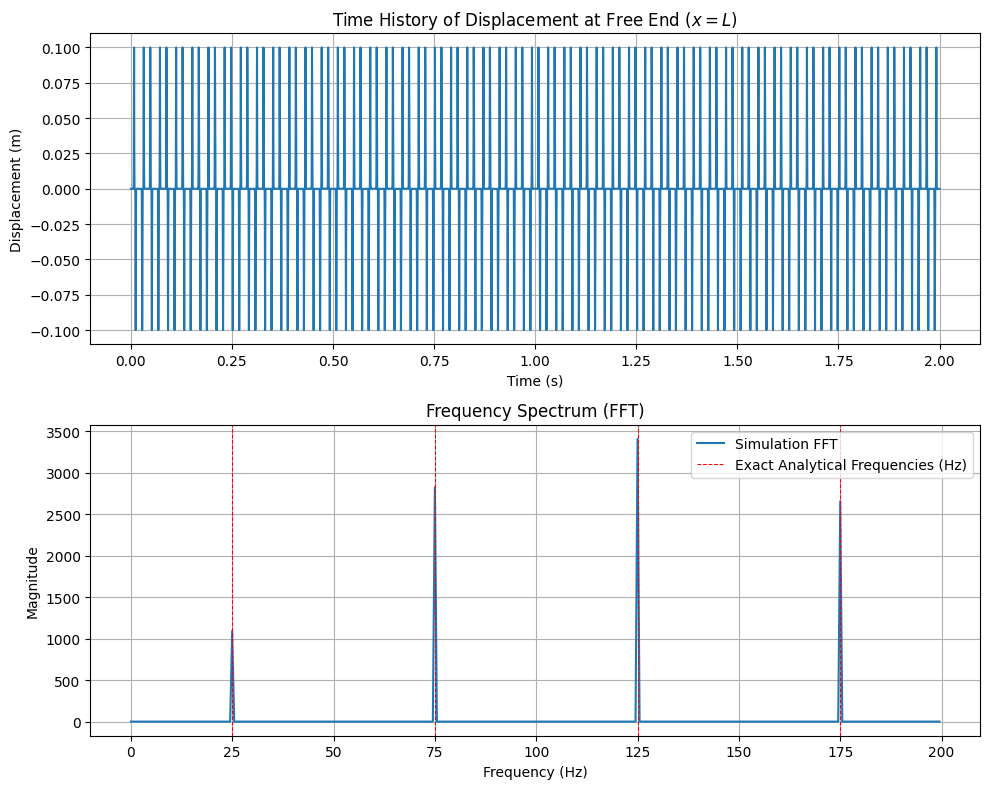

In [20]:
# plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# time history
ax1.plot(TIME, sensor_data)
ax1.set_title('Time History of Displacement at Free End ($x=L$)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Displacement (m)')
ax1.grid(True)

# frequency spectrum
ax2.plot(freqs[:max_freq_idx], fft_mag[:max_freq_idx], label="Simulation FFT")
ax2.set_title('Frequency Spectrum (FFT)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True)
# plot exact analytical frequencies
exact_freqs = [25, 75, 125, 175]
for f in exact_freqs:
  ax2.axvline(f, color='red', linestyle='--', linewidth=0.75,
      label='Exact Analytical Frequencies (Hz)' if f == 25 else "")
ax2.legend()
plt.tight_layout()
plt.show()

As we see, the numerical simulation frequency data matches that calculated analytically. We see the baseline simulation speed using the largest time step size that retains numerical stability for our given cable discretization (2000 nodes) is approximately 5 seconds.

Now we will see if we can train a PINN to significantly reduce the simulation time.

## Physics Informed Neural Network (PINN)

### PINN for the 1D Wave Equation

Unlike traditional numerical methods (like Finite Difference or Finite Element Methods) that require discretizing space and time into a rigid grid, a PINN solves partial differential equations in a mesh-free, continuous domain. This methodology leverages the neural network as a universal function approximator governed directly by the underlying physical laws.

#### 1. Continuous Approximation
In a PINN, the unknown displacement field $w(x,t)$ is approximated by a deep neural network, denoted as $w_{NN}$. The network takes continuous spatial coordinates $x$ and continuous time $t$ as direct inputs and outputs the predicted displacement:
$$w_{NN}(x, t) = \mathcal{N}(x, t; \boldsymbol{\theta})$$
Where $\boldsymbol{\theta}$ represents the trainable parameters (weights and biases) of the neural network.

#### 2. Automatic Differentiation (AD)
Traditional solvers use finite difference or other methods to approximate derivatives, which introduce truncation errors and stability limits (like the CFL condition). PINNs avoid this entirely by using Automatic Differentiation (AD). 

AD applies the chain rule recursively to compute the exact analytical derivatives of the network's output with respect to its inputs. This allows us to exactly evaluate the spatial and temporal partial derivatives required by the governing PDE:
* Velocity: $\frac{\partial w_{NN}}{\partial t}$
* Spatial curvature: $\frac{\partial^2 w_{NN}}{\partial x^2}$
* Acceleration: $\frac{\partial^2 w_{NN}}{\partial t^2}$

#### 3. The Composite Loss Function
The network is trained by minimizing a composite loss function that enforces the physics, initial conditions, and boundary conditions evaluated at randomly sampled collocation points within the domain.

**A. The Physics Loss (PDE Residual):**
We sample $N_{PDE}$ collocation points $(x_i, t_i)$ randomly across the spatiotemporal domain. The physics loss penalizes any output that does not satisfy the 1D wave equation ($P \frac{\partial^2 w}{\partial x^2} = \rho \frac{\partial^2 w}{\partial t^2}$):
$$\mathcal{L}_{PDE} = \frac{1}{N_{PDE}} \sum_{i=1}^{N_{PDE}} \left| \rho \frac{\partial^2 w_{NN}(x_i, t_i)}{\partial t^2} - P \frac{\partial^2 w_{NN}(x_i, t_i)}{\partial x^2} \right|^2$$

**B. The Initial Condition (IC) Loss:**
We sample $N_{IC}$ points $(x_j, 0)$ at $t=0$. This loss enforces the initial spatial displacement field $w_0(x)$ and initial velocity $v_0(x)$:
$$\mathcal{L}_{IC} = \frac{1}{N_{IC}} \sum_{j=1}^{N_{IC}} \left( \left| w_{NN}(x_j, 0) - w_0(x_j) \right|^2 + \left| \frac{\partial w_{NN}(x_j, 0)}{\partial t} - v_0(x_j) \right|^2 \right)$$

**C. The Boundary Condition (BC) Loss:**
We sample $N_{BC}$ points at the edges of the spatial domain over time, $(0, t_k)$ and $(l, t_k)$, to enforce the fixed-free constraints:
* **Fixed End ($x=0$):** $w(0,t) = 0$
* **Free End ($x=l$):** $P \frac{\partial w(l,t)}{\partial x} = 0$

$$\mathcal{L}_{BC} = \frac{1}{N_{BC}} \sum_{k=1}^{N_{BC}} \left( \left| w_{NN}(0, t_k) \right|^2 + \left| P \frac{\partial w_{NN}(l, t_k)}{\partial x} \right|^2 \right)$$

#### 4. Training and Optimization
The total loss is the weighted sum of these components:
$$\mathcal{L}_{Total} = \lambda_{PDE}\mathcal{L}_{PDE} + \lambda_{IC}\mathcal{L}_{IC} + \lambda_{BC}\mathcal{L}_{BC}$$
*(Where $\lambda$ terms are hyperparameters used to balance the gradients of the different loss components).*

For better accuracy, an additional loss term $\mathcal{L}_{meas}$ can be introduced to check the solution against measured points. In this case, we will attempt to train the PINN without this additional term, assuming we are unable to make any measurements or generate any fictitious points from analytical solutions.

The network is trained by iteratively updating the parameters $\boldsymbol{\theta}$ using gradient-based optimizers (typically Adam followed by L-BFGS) until $\mathcal{L}_{Total}$ converges near zero. Once trained, the network represents a closed-form, continuous, and fully differentiable analytical approximation of the string's motion.

### PINN Implementation

Here, we set up our PINN parameters and move our core data to the GPU.

In [21]:
import torch


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device(DEVICE)
print(f'Device = {torch.get_default_device()}')

Device = cuda:0


In [22]:
# general PINN class definition with simple network
class PINN(torch.nn.Module):
  def __init__(self, input_dim=2, hidden_dim=64, output_dim=1, num_hidden_layers=4):
    super().__init__()
    layers = [torch.nn.Linear(input_dim, hidden_dim), torch.nn.Tanh()]
    for _ in range(num_hidden_layers - 1):
      layers += [torch.nn.Linear(hidden_dim, hidden_dim), torch.nn.Tanh()]
    layers += [torch.nn.Linear(hidden_dim, output_dim)]
    self.net = torch.nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)
  

# class specific for the wave equation
class WaveEquationDataset(object):
  def __init__(self, n_col, n_ic, n_bc, tension=TENSION, density=DENSITY):
        self.P = tension
        self.rho = density
        self.n_col = n_col # collocation points
        self.n_ic = n_ic # initial-condition points
        self.n_bc = n_bc # boundary-condition points (per boundary)

        # --- collocation points: x in (0,L), t in (0,T) ---
        self.x_c = (LENGTH * torch.rand(n_col, 1)).requires_grad_(True) # (0,1)
        self.t_c = (TOTAL_TIME * torch.rand(n_col, 1)).requires_grad_(True) # (0,2)
        self.Xc = torch.cat((self.x_c, self.t_c), dim=1)
        self.f_target = torch.zeros(self.Xc.shape[0], 1) # PDE residual should = 0

        # --- initial condition points: t = 0, x in (0,L) ---
        self.x_i = torch.linspace(0, LENGTH, n_ic).view(-1, 1).requires_grad_(True) # (0,1)
        self.t_i = torch.zeros_like(self.x_i) # t=0
        self.Xi = torch.cat((self.x_i, self.t_i), dim=1)
        # initial displacement target
        self.Ui = PULSE_SCALE * torch.exp(-((self.x_i - PULSE_MEAN) / PULSE_SIGMA)**2)
        # inital velocity target (v = dw/dt)
        self.Vi = torch.zeros_like(self.Ui)

        # --- boundary points: x = 0 and x = L, t in (0,T) ---
        # fixed left boundary (x = 0)
        self.t_b0 = TOTAL_TIME * torch.rand(self.n_bc, 1) # random times in time domain
        self.x_b0 = torch.zeros_like(self.t_b0) # along x = 0
        self.Xb0 = torch.cat((self.x_b0, self.t_b0), dim=1)
        self.Ub0 = torch.zeros(self.Xb0.shape[0], 1) # target displacement = 0
        # free right boundary (x = L)
        self.t_b1 = TOTAL_TIME * torch.rand(self.n_bc, 1)
        self.x_b1 = (LENGTH * torch.ones_like(self.t_b1)).requires_grad_(True)
        self.Xb1 = torch.cat((self.x_b1, self.t_b1), dim=1)
        # we do not define Ub1 here as our target BC is slope = 0

## References
- **Hughes, T. J. R. (2012).** The Finite Element Method: Linear Static and Dynamic Finite Element Analysis. Dover Publications.
- **LeVeque, R. J. (2007).** Finite Difference Methods for Ordinary and Partial Differential Equations: Steady-State and Time-Dependent Problems. Society for Industrial and Applied Mathematics (SIAM).
- **Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019).** Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. Journal of Computational Physics, 378, 686-707.
- **Karniadakis, G. E., Kevrekidis, I. G., Lu, L., Perdikaris, P., Wang, S., & Yang, L. (2021).** Physics-informed machine learning. Nature Reviews Physics, 3(6), 422-440.